# Installation, Importing and Initialization

In [1]:
#install all required packages
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

#list of required packages
packages = [
    'groq',
    'supabase',
    'sentence-transformers>=2.2.0',
    'torch',
    'transformers>=4.34.0',
    'langchain',
    'langchain-groq',
    'langchain-community',
    'langgraph',
    'python-dotenv'
]

for package in packages:
    install_package(package)
    print(f"{package} installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 5.2 MB/s eta 0:00:00
groq installed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.8 MB/s eta 0:00:00
supabase installed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


sentence-transformers>=2.2.0 installed
torch installed
transformers>=4.34.0 installed
langchain installed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 11.4 MB/s eta 0:00:00
langchain-groq installed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 5.3 MB/s eta 0:00:00
langchain-community installed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.4/207.4 kB 9.6 MB/s eta 0:00:00
langgraph installed
python-dotenv installed


In [2]:
#import all libraries
import os
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from groq import Groq
from supabase import create_client, Client
import json
import re
from datetime import datetime
from typing import List, Dict, Tuple, Optional, Any
from dataclasses import dataclass
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

#langchain and langgraph imports
from langchain_core.tools import tool
from typing_extensions import TypedDict 
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, ToolMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_groq import ChatGroq
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from dotenv import load_dotenv

print("All libraries imported")

2025-10-12 04:03:42.427633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760241822.724090      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760241822.811288      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


All libraries imported


In [3]:
#import kaggle secrets
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

#environment setup
load_dotenv()

#retrieve credentials from kaggle secrets
SUPABASE_URL = user_secrets.get_secret("SUPABASE_URL")
SUPABASE_KEY = user_secrets.get_secret("SUPABASE_KEY")
GROQ_API_KEY = user_secrets.get_secret("GROQ_API_KEY")

#set environment variable for groq
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [4]:
#supabase client setup
supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Supabase client initialized")

#groq client setup
if not GROQ_API_KEY:
    print("please add your groq api key")
else:
    groq_client = Groq(api_key=GROQ_API_KEY)
    print("Groq client initialized successfully")

Supabase client initialized
Groq client initialized successfully


# CBT Techniques

In [5]:
#cbt technique enum
class CBTTechnique(Enum):
    COGNITIVE_RESTRUCTURING = "cognitive_restructuring"
    BEHAVIORAL_ACTIVATION = "behavioral_activation"
    GROUNDING = "grounding"
    PROBLEM_SOLVING = "problem_solving"
    MINDFULNESS = "mindfulness"
    EMOTION_REGULATION = "emotion_regulation"

#fetch technique profiles from supabase
def fetch_technique_profiles():
    """fetch all cbt technique profiles from supabase database"""
    try:
        response = supabase.table('cbt_techniques').select('*').execute()
        
        if not response.data:
            raise Exception("no technique profiles found in database")
        
        #convert database rows to technique_profiles dictionary
        profiles = {}
        
        for row in response.data:
            #map technique_name to enum
            technique_key = CBTTechnique(row['technique_name'])
            
            profiles[technique_key] = {
                'description': row['description'],
                'example_phrases': row['example_phrases'],
                'indicators': row['indicators'],
                'emotional_states': row['emotional_states'],
                'when_to_use': row['when_to_use'],
                'when_not_to_use': row['when_not_to_use']
            }
        
        return profiles
        
    except Exception as e:
        print(f"Error fetching technique profiles: {str(e)}")
        raise

#fetch profiles from database
TECHNIQUE_PROFILES = fetch_technique_profiles()

#technique distinctions
TECHNIQUE_DISTINCTIONS = {
    "COGNITIVE_RESTRUCTURING vs MINDFULNESS": 
        "Cognitive restructuring CHALLENGES and CHANGES thoughts; mindfulness OBSERVES and ACCEPTS thoughts without changing them",
    
    "GROUNDING vs MINDFULNESS":
        "Grounding is for ACUTE distress/panic (immediate relief); mindfulness is for CHRONIC rumination/worry (long-term practice)",
    
    "BEHAVIORAL_ACTIVATION vs PROBLEM_SOLVING":
        "Behavioral activation addresses MOOD through activity; problem-solving addresses PRACTICAL issues through planning",
    
    "EMOTION_REGULATION vs GROUNDING":
        "Emotion regulation teaches SKILLS for managing intense emotions; grounding provides IMMEDIATE relief from acute distress"
}

#safe fallback techniques
SAFE_FALLBACK_TECHNIQUES = [
    CBTTechnique.MINDFULNESS,
    CBTTechnique.GROUNDING
]

print(f"Loaded {len(TECHNIQUE_PROFILES)} CBT technique profiles from Supabase")

Loaded 6 CBT technique profiles from Supabase


In [6]:
#initialize sentence transformer for embeddings
print("="*50)
print("loading embedding model")
print("="*50)

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

#pre-compute embeddings for all technique example phrases
technique_embeddings = {}
for technique, profile in TECHNIQUE_PROFILES.items():
    #combine description and example phrases for embedding
    texts_to_embed = [profile["description"]] + profile["example_phrases"]
    
    #compute embeddings
    embeddings = embedding_model.encode(texts_to_embed)
    
    #store mean embedding for the technique
    technique_embeddings[technique] = np.mean(embeddings, axis=0)

print(f"Embedding model loaded and {len(technique_embeddings)} technique embeddings computed")

loading embedding model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding model loaded and 6 technique embeddings computed


In [7]:
#embedding-based technique selection
def select_technique_by_embedding(user_input: str, top_k: int = 3) -> List[Tuple[CBTTechnique, float]]:
    """
    select cbt techniques using semantic similarity
    returns top_k techniques with confidence scores
    """
    #encode user input
    user_embedding = embedding_model.encode([user_input])[0]
    
    #calculate similarities with all techniques
    similarities = {}
    for technique, technique_embedding in technique_embeddings.items():
        #cosine similarity between user input and technique
        similarity = cosine_similarity(
            user_embedding.reshape(1, -1),
            technique_embedding.reshape(1, -1)
        )[0][0]
        similarities[technique] = similarity
    
    #sort by similarity and get top k
    sorted_techniques = sorted(
        similarities.items(), 
        key=lambda x: x[1], 
        reverse=True
    )[:top_k]
    
    return sorted_techniques

print("Embedding-based technique selection configured")

Embedding-based technique selection configured


# Checks

In [12]:
#llm-based scope detection
def detect_scope_with_llm(user_input: str) -> Tuple[str, str, str]:
    """
    use llm to detect if input is appropriate for cbt chatbot
    returns (scope_category, reason, response_message)
    
    scope_category: "cbt_appropriate", "specialized_mental_health", "not_mental_health"
    """
    #cell 8 - updated scope_prompt
    scope_prompt = f"""you are a mental health scope detector. your job is to determine if a user's input is appropriate for a CBT chatbot or if it requires a different response.
    
    user input: "{user_input}"
    
    classify this input into ONE of these three categories:
    
    1. CBT_APPROPRIATE: general mental health concerns suitable for CBT chatbot
       - anxiety, worry, stress about situations
       - negative thought patterns, self-criticism
       - depression, low mood, lack of motivation
       - difficulty with emotions or behaviors
       - general psychological distress
       - panic attack symptoms (racing heart, can't breathe, feeling overwhelmed) - these benefit from grounding techniques
       - acute anxiety or stress responses
    
    2. SPECIALIZED_MENTAL_HEALTH: serious conditions requiring professional care
       - eating disorders (restriction, binging, purging, body image obsession)
       - self-harm or suicidal ideation
       - psychosis, delusions, hallucinations, paranoia
       - mania, extreme mood swings, no sleep for days
       - severe trauma, PTSD flashbacks
       - substance abuse as primary concern
       - severe dissociation or identity issues
       - medical emergencies (chest pain with other cardiac symptoms, loss of consciousness)
    
    3. NOT_MENTAL_HEALTH: casual conversation or unrelated topics
       - greetings ("hi", "hello", "how are you")
       - chitchat or social pleasantries
       - factual questions unrelated to mental health
       - technical questions, general advice
       - sharing positive experiences without distress
    
    CRITICAL: 
    - panic attack symptoms (racing heart, can't breathe, feeling anxious/panicky) are CBT_APPROPRIATE and benefit from grounding techniques
    - only classify as SPECIALIZED_MENTAL_HEALTH if there are signs of actual medical emergency (chest pain with arm pain, loss of consciousness) or severe psychiatric symptoms
    - if there's ANY indication of eating disorder behavior, self-harm, or suicidal ideation, classify as SPECIALIZED_MENTAL_HEALTH even if the user seems casual about it.
    
    respond in this exact format:
    CATEGORY: [CBT_APPROPRIATE/SPECIALIZED_MENTAL_HEALTH/NOT_MENTAL_HEALTH]
    REASON: [one sentence explaining why this category fits]
    RESPONSE: [if SPECIALIZED_MENTAL_HEALTH, provide crisis referral message. otherwise write "None needed"]
    
    examples:
    
    input: "I'm really anxious about my job interview tomorrow"
    CATEGORY: CBT_APPROPRIATE
    REASON: user expresses normal anxiety about a specific situation that CBT can help with.
    RESPONSE: None needed
    
    input: "I can't breathe, my heart is racing, I think I'm having a panic attack"
    CATEGORY: CBT_APPROPRIATE
    REASON: user describes panic attack symptoms which are highly appropriate for CBT grounding techniques.
    RESPONSE: None needed
    
    input: "I have chest pain radiating to my left arm and I feel dizzy"
    CATEGORY: SPECIALIZED_MENTAL_HEALTH
    REASON: these symptoms suggest a possible cardiac emergency requiring immediate medical attention.
    RESPONSE: what you're describing sounds like it could be a medical emergency. please call emergency services immediately or go to the nearest emergency room. if you're having chest pain with arm pain and dizziness, this needs urgent medical evaluation.
    
    input: "I ate too much today so I need to skip meals tomorrow to make up for it"
    CATEGORY: SPECIALIZED_MENTAL_HEALTH
    REASON: this indicates disordered eating patterns involving restriction and compensation that require specialized eating disorder treatment.
    RESPONSE: I'm concerned about what you're sharing. thoughts about compensating for eating through restriction can be part of disordered eating patterns that benefit from specialized support. I'd strongly encourage you to speak with a healthcare provider, therapist specializing in eating disorders, or contact the national eating disorders association helpline at 1-800-931-2237. this is important and you deserve proper support.
    
    input: "what should I eat for dinner tonight?"
    CATEGORY: NOT_MENTAL_HEALTH
    REASON: this is a casual food choice question with no indication of mental health concerns.
    RESPONSE: None needed
    
    input: "I keep hearing voices telling me people are plotting against me"
    CATEGORY: SPECIALIZED_MENTAL_HEALTH
    REASON: user reports hallucinations and paranoid delusions which require immediate professional psychiatric evaluation.
    RESPONSE: what you're experiencing sounds very distressing. hearing voices and feeling that others are plotting against you are symptoms that need professional psychiatric care. please reach out to a mental health professional, call a crisis line, or go to an emergency room if you feel unsafe. you can also call 988 (suicide and crisis lifeline) for immediate support.
    
    input: "hi there! how are you doing today?"
    CATEGORY: NOT_MENTAL_HEALTH
    REASON: this is a casual greeting with no indication of mental health concerns.
    RESPONSE: None needed"""

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "user", "content": scope_prompt}
            ],
            temperature=0.2,
            max_tokens=300
        )
        
        response_text = response.choices[0].message.content.strip()
        
        #parse response
        lines = response_text.split('\n')
        category = "cbt_appropriate"
        reason = "classification unclear"
        response_message = ""
        
        for line in lines:
            if line.startswith('CATEGORY:'):
                category_raw = line.replace('CATEGORY:', '').strip().lower()
                if 'specialized' in category_raw:
                    category = "specialized_mental_health"
                elif 'not_mental_health' in category_raw or 'not mental health' in category_raw:
                    category = "not_mental_health"
                else:
                    category = "cbt_appropriate"
            elif line.startswith('REASON:'):
                reason = line.replace('REASON:', '').strip()
            elif line.startswith('RESPONSE:'):
                response_message = line.replace('RESPONSE:', '').strip()
                if response_message.lower() == "none needed":
                    response_message = ""
        
        return category, reason, response_message
        
    except Exception as e:
        return "cbt_appropriate", f"detection error: {str(e)}", ""

print("LLM-based scope detection configured")

LLM-based scope detection configured


In [13]:
#casual conversation response generator
def generate_casual_response(user_input: str) -> str:
    """generate contextual response for non-mental health questions"""
    casual_prompt = f"""you are a mental health chatbot, but the user has asked you a casual question unrelated to mental health.

user input: "{user_input}"

respond to their question in a brief, natural, and helpful way. just answer their question directly in 1-2 sentences. be warm and conversational.

do NOT remind them you're a mental health chatbot or ask if they have mental health concerns. just answer naturally like a helpful friend would.

examples:

user: "what should I eat for dinner tonight?"
response: that depends on what you're craving! maybe something balanced with protein and veggies if you want to feel satisfied and energized.

user: "what's the weather like?"
response: I don't have access to current weather data, but you can check your weather app for the most accurate forecast in your area.

user: "tell me a joke"
response: why don't scientists trust atoms? because they make up everything! not my best work, but hopefully it got a smile.

user: "how are you?"
response: I'm doing well, thanks for asking! how are you doing today?

now respond to: "{user_input}" """
    
    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "user", "content": casual_prompt}
            ],
            temperature=0.7,
            max_tokens=150
        )
        
        response_text = response.choices[0].message.content.strip()
        
        #remove surrounding quotes if present
        if response_text.startswith('"') and response_text.endswith('"'):
            response_text = response_text[1:-1]
        elif response_text.startswith("'") and response_text.endswith("'"):
            response_text = response_text[1:-1]
        
        return response_text
        
    except Exception as e:
        return "I'm here to chat! What's on your mind?"

print("Casual conversation response generator configured")

Casual conversation response generator configured


In [14]:
#llm-based ambiguity detection
def detect_ambiguity_with_llm(user_input: str) -> Tuple[bool, str, str]:
    """
    use llm to detect if user input is too ambiguous to select a technique
    returns (is_ambiguous, reason, clarification_response)
    """
    ambiguity_prompt = f"""You are an expert at assessing whether user inputs contain enough information for a mental health chatbot to provide meaningful support.

User Input: "{user_input}"

Question: Is this input clear enough to understand what kind of support the user needs, or is it too vague/ambiguous?

Consider:
- Does the input express a specific thought, feeling, or situation?
- Can you understand what the user is struggling with?
- Is there enough context to provide targeted support?

Inputs that are TOO AMBIGUOUS:
- Single words like "help", "bad", "stressed" without context
- Very vague statements like "I feel weird" or "something's wrong"
- Inputs that could mean many different things

Inputs that are CLEAR ENOUGH:
- Specific emotions or thoughts even if brief ("I'm anxious about my presentation")
- Clear problems even if short ("I can't sleep")
- Specific situations ("my boss yelled at me")

Respond in this exact format:
AMBIGUOUS: [YES/NO]
REASON: [Brief explanation in one sentence]
CLARIFICATION: [If ambiguous, suggest what clarifying question to ask. If not ambiguous, write "None needed"]

Examples:
AMBIGUOUS: YES
REASON: Single word "help" provides no context about what the user needs help with.
CLARIFICATION: I'm here to help. Could you tell me more about what's troubling you right now?

AMBIGUOUS: NO
REASON: User clearly expresses feeling anxious with specific context.
CLARIFICATION: None needed"""

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "user", "content": ambiguity_prompt}
            ],
            temperature=0.3,
            max_tokens=200
        )
        
        response_text = response.choices[0].message.content.strip()
        
        #parse response
        lines = response_text.split('\n')
        is_ambiguous = False
        reason = "no reason provided"
        clarification = "could you tell me more about what's on your mind?"
        
        for line in lines:
            if line.startswith('AMBIGUOUS:'):
                is_ambiguous = 'YES' in line.upper()
            elif line.startswith('REASON:'):
                reason = line.replace('REASON:', '').strip()
            elif line.startswith('CLARIFICATION:'):
                clarification = line.replace('CLARIFICATION:', '').strip()
                if clarification.lower() == "none needed":
                    clarification = ""
        
        return is_ambiguous, reason, clarification
        
    except Exception as e:
        return False, f"detection error: {str(e)}", ""

print("LLM-based ambiguity detection configured")

LLM-based ambiguity detection configured


In [15]:
#llm-based technique validation
def validate_technique_with_llm(user_input: str, technique: CBTTechnique) -> Tuple[bool, str]:
    """
    use llm to validate if selected technique is appropriate
    returns (is_appropriate, reasoning)
    """
    #get technique profile for enhanced context
    profile = TECHNIQUE_PROFILES[technique]
    
    #get relevant distinctions for this technique
    relevant_distinctions = []
    for comparison, distinction in TECHNIQUE_DISTINCTIONS.items():
        if technique.value.upper() in comparison.upper():
            relevant_distinctions.append(f"- {comparison}: {distinction}")
    
    distinctions_text = "\n".join(relevant_distinctions) if relevant_distinctions else ""
    
    validation_prompt = f"""you are a CBT expert validator. your job is to determine if a selected CBT technique is appropriate for a given user input.

user input: "{user_input}"

selected technique: {technique.value.replace('_', ' ').title()}

technique information:
- description: {profile['description']}
- common indicators: {', '.join(profile['indicators'])}
- typical emotional states: {', '.join(profile['emotional_states'])}
- when to use: {profile['when_to_use']}
- when NOT to use: {profile['when_not_to_use']}

{f'important distinctions:{distinctions_text}' if distinctions_text else ''}

question: is this technique appropriate and safe to use for this user input?

consider:
- is this the most helpful technique for this specific situation?
- are there any safety concerns (e.g., crisis situations)?
- does the technique match the emotional/psychological state implied?
- do any of the "when NOT to use" conditions apply?
- do the indicators and emotional states match the user's situation?
- are there other techniques that would be more appropriate based on the distinctions above?

respond in this exact format:
APPROPRIATE: [YES/NO]
REASONING: [brief explanation in one sentence]

example responses:
APPROPRIATE: YES
REASONING: cognitive restructuring is appropriate for challenging negative self-beliefs.

APPROPRIATE: NO
REASONING: user is experiencing panic symptoms and needs grounding, not cognitive restructuring."""
    
    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "user", "content": validation_prompt}
            ],
            temperature=0.3,
            max_tokens=150
        )
        
        response_text = response.choices[0].message.content.strip()
        
        #parse response
        lines = response_text.split('\n')
        is_appropriate = False
        reasoning = "no reasoning provided"
        
        for line in lines:
            if line.startswith('APPROPRIATE:'):
                is_appropriate = 'YES' in line.upper()
            elif line.startswith('REASONING:'):
                reasoning = line.replace('REASONING:', '').strip()
        
        return is_appropriate, reasoning
        
    except Exception as e:
        return False, f"validation error: {str(e)}"

print("LLM validation function created")

LLM validation function created


In [16]:
class CBTScopeDetector:
    """scope detector for cbt chatbot to determine response type"""
    
    def __init__(self):
        self.detection_history = []
    
    def detect_scope(self, user_input: str) -> Dict[str, Any]:
        """
        detect if user input requires cbt, specialized care, or casual response
        returns comprehensive metadata for agent decision making
        """
        #step 1: scope detection
        scope_category, scope_reason, scope_response = detect_scope_with_llm(user_input)
        
        result = {
            "scope_category": scope_category,
            "scope_reason": scope_reason,
            "scope_response": scope_response,
            "user_input": user_input
        }
        
        #if cbt appropriate, do full technique selection pipeline
        if scope_category == "cbt_appropriate":
            #step 2: ambiguity check
            is_ambiguous, ambiguity_reason, clarification_response = detect_ambiguity_with_llm(user_input)
            
            if is_ambiguous:
                result.update({
                    "needs_clarification": True,
                    "clarification_response": clarification_response,
                    "ambiguity_reason": ambiguity_reason
                })
                return result
            
            #step 3: technique selection with validation
            embedding_results = select_technique_by_embedding(user_input, top_k=3)
            validation_attempts = []
            selected_technique = None
            
            #validate top 3 techniques
            for technique, similarity_score in embedding_results:
                is_appropriate, reasoning = validate_technique_with_llm(user_input, technique)
                
                validation_attempts.append({
                    "technique": technique.value,
                    "similarity_score": float(similarity_score),
                    "is_appropriate": is_appropriate,
                    "reasoning": reasoning
                })
                
                if is_appropriate:
                    selected_technique = technique
                    break
            
            #step 4: fallback if all rejected
            if selected_technique is None:
                fallback_validations = []
                
                #validate all fallback techniques
                for fallback_technique in SAFE_FALLBACK_TECHNIQUES:
                    is_appropriate, reasoning = validate_technique_with_llm(user_input, fallback_technique)
                    
                    fallback_validations.append({
                        "technique": fallback_technique.value,
                        "similarity_score": 0.0,
                        "is_appropriate": is_appropriate,
                        "reasoning": reasoning,
                        "is_fallback": True
                    })
                
                validation_attempts.extend(fallback_validations)
                
                #get approved fallbacks
                approved_fallbacks = [fv for fv in fallback_validations if fv["is_appropriate"]]
                
                if len(approved_fallbacks) == 0:
                    #no fallbacks approved, choose best between the two
                    selected_technique = self._choose_best_fallback_forced(user_input, SAFE_FALLBACK_TECHNIQUES)
                    validation_attempts.append({
                        "technique": selected_technique.value,
                        "similarity_score": 0.0,
                        "is_appropriate": False,
                        "reasoning": f"forced fallback - chose {selected_technique.value} as more suitable than alternatives",
                        "is_fallback": True,
                        "is_forced": True
                    })
                elif len(approved_fallbacks) == 1:
                    #only one approved, use it
                    selected_technique = CBTTechnique(approved_fallbacks[0]["technique"])
                else:
                    #multiple fallbacks approved, choose best one
                    selected_technique = self._choose_best_fallback_approved(user_input, approved_fallbacks)
                    validation_attempts.append({
                        "technique": selected_technique.value,
                        "similarity_score": 0.0,
                        "is_appropriate": True,
                        "reasoning": f"selected {selected_technique.value} as most suitable among approved fallbacks",
                        "is_fallback": True,
                        "is_best_choice": True
                    })
            
            result.update({
                "needs_clarification": False,
                "selected_technique": selected_technique.value,
                "technique_description": TECHNIQUE_PROFILES[selected_technique]['description'],
                "embedding_results": [(tech.value, float(score)) for tech, score in embedding_results],
                "validation_attempts": validation_attempts
            })
        
        self.detection_history.append(result)
        return result
    
    def _choose_best_fallback_forced(self, user_input: str, fallback_techniques: List[CBTTechnique]) -> CBTTechnique:
        """
        use llm to choose the most suitable fallback when all options were rejected
        compares mindfulness vs grounding to pick better fit
        """
        #create comparison prompt
        options_text = "\n".join([
            f"- {tech.value.replace('_', ' ').title()}: {TECHNIQUE_PROFILES[tech]['description']}"
            for tech in fallback_techniques
        ])
        
        comparison_prompt = f"""you are a cbt expert. all specific techniques were rejected for this user input, but you must choose the most suitable safe fallback technique.
user input: "{user_input}"
available fallback options:
{options_text}
question: which fallback technique is most suitable for this user's situation?
consider:
- mindfulness is better for: general worry, rumination, racing thoughts, wanting to observe without judgment
- grounding is better for: panic, acute distress, dissociation, feeling overwhelmed, needing immediate calming
respond in this exact format:
SELECTED: [technique name exactly as shown above]
REASON: [one sentence explaining why this is more suitable]"""
        
        try:
            response = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[
                    {"role": "user", "content": comparison_prompt}
                ],
                temperature=0.3,
                max_tokens=150
            )
            
            response_text = response.choices[0].message.content.strip()
            
            #parse response to get selected technique
            for line in response_text.split('\n'):
                if line.startswith('SELECTED:'):
                    selected_name = line.replace('SELECTED:', '').strip().lower()
                    #match to technique enum
                    for tech in fallback_techniques:
                        if tech.value.replace('_', ' ') in selected_name or tech.value in selected_name:
                            return tech
            
            #default to mindfulness if parsing fails
            return fallback_techniques[0]
        
        except Exception as e:
            #default to mindfulness if llm call fails
            return fallback_techniques[0]
    
    def _choose_best_fallback_approved(self, user_input: str, approved_fallbacks: List[Dict]) -> CBTTechnique:
        """
        use llm to choose best technique among multiple approved fallbacks
        """
        options_text = "\n".join([
            f"- {fb['technique'].replace('_', ' ').title()}: {fb['reasoning']}"
            for fb in approved_fallbacks
        ])
        
        selection_prompt = f"""you are a CBT expert. multiple fallback techniques are appropriate for this user input, but you must select the most appropriate one.
user input: "{user_input}"
approved fallback options:
{options_text}
question: which technique is most appropriate for this specific situation?
respond in this exact format:
SELECTED: [technique name exactly as shown above]
REASON: [one sentence explaining why this is most appropriate]"""
        
        try:
            response = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[
                    {"role": "user", "content": selection_prompt}
                ],
                temperature=0.3,
                max_tokens=150
            )
            
            response_text = response.choices[0].message.content.strip()
            
            #parse response to get selected technique
            for line in response_text.split('\n'):
                if line.startswith('SELECTED:'):
                    selected_name = line.replace('SELECTED:', '').strip().lower()
                    #match to technique in approved_fallbacks
                    for fb in approved_fallbacks:
                        if fb['technique'].replace('_', ' ') in selected_name or fb['technique'] in selected_name:
                            return CBTTechnique(fb['technique'])
            
            #default to first approved fallback if parsing fails
            return CBTTechnique(approved_fallbacks[0]['technique'])
        
        except Exception as e:
            #default to first approved fallback if llm call fails
            return CBTTechnique(approved_fallbacks[0]['technique'])

#initialize detector
cbt_detector = CBTScopeDetector()

@tool
def detect_cbt_scope(user_input: str) -> dict:
    """
    use this tool for every user message to determine what type of response is needed.
    this tool detects if the user needs:
    1. cbt therapeutic response (returns selected technique and validation info)
    2. crisis/specialized mental health referral (out of scope)
    3. casual conversational response (not mental health related)
    
    the input should be the user's most recent message.
    """
    if cbt_detector:
        return cbt_detector.detect_scope(user_input)
    return {"Error": "CBT scope detector is unavailable"}

print("CBT scope detection tool initialized")

CBT scope detection tool initialized


In [17]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print("State definition created")

State definition created


In [18]:
tools = [detect_cbt_scope]
print("Tools list configured")

Tools list configured


In [19]:
system_prompt = """you are a compassionate Cognitive Behavioral Therapy mental health assistant. your role is to provide emotional support using evidence-based cbt techniques.

critical instruction: call the detect_cbt_scope tool only once per user message, then provide your response. do not call the tool again after receiving the results.

workflow:
1. when you receive a new user message, call detect_cbt_scope tool
2. read the tool's output carefully
3. provide your final response based on the tool output - do not call any tools again

based on the tool's output, follow these guidelines:

1. if scope_category is "specialized_mental_health":
   - use the exact scope_response provided by the tool
   - this contains crisis referral information
   - do not add cbt guidance or techniques
   - be direct, clear, and supportive

2. if scope_category is "not_mental_health":
   - respond naturally and casually to their question
   - be warm and helpful like a friend
   - answer their question directly in 1-2 sentences
   - do not force mental health topics into the conversation
   - do not remind them you're a mental health bot

3. if needs_clarification is true:
   - use the clarification_response provided by the tool
   - ask for more context in a warm, supportive way
   - do not try to provide cbt guidance yet

4. if scope_category is "cbt_appropriate" and a technique is selected:
   - start with empathy and validation of their feelings
   - apply the specific cbt technique indicated (cognitive_restructuring, behavioral_activation, grounding, problem_solving, mindfulness, or emotion_regulation)
   - use the technique_description as your guide
   - follow cbt best practices:
     * for cognitive_restructuring: identify negative thoughts, examine evidence, develop balanced alternatives
     * for behavioral_activation: suggest small achievable activities aligned with values
     * for grounding: guide through 5-4-3-2-1 technique or breathing exercises
     * for problem_solving: help define problem, generate solutions, create action steps
     * for mindfulness: guide present-moment awareness without judgment
     * for emotion_regulation: validate emotions, teach healthy coping strategies
   - Keep responses brief and conversational (2-3 short paragraphs, 80-120 words max)
   - Focus on ONE main point or action per response
   - Avoid lengthy explanations - users can ask follow-up questions
   - End with a single focused question when appropriate
   - use collaborative language ("let's explore", "we can work on")

important boundaries:
- you are not a licensed therapist
- encourage professional help for persistent or severe symptoms
- never diagnose conditions or prescribe treatments
- maintain supportive, non-judgmental tone

remember: call detect_cbt_scope tool once, get results, then respond. never call tools in your final response."""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    MessagesPlaceholder(variable_name="messages"),
])

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7, max_tokens=200)
llm_with_tools = llm.bind_tools(tools)
chain = prompt | llm_with_tools

print("LLM and prompt configured")

LLM and prompt configured


In [20]:
#node definition
def tool_calling_llm(state: State):
    """the node that calls the llm with system prompt and tools"""
    response = chain.invoke({"messages": state["messages"]})
    return {"messages": [response]}

#build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

#build edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()

print("LangGraph compiled successfully")

LangGraph compiled successfully


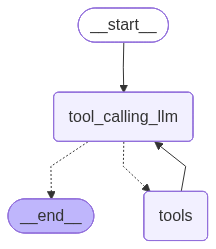

In [21]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
#test cases
test_messages = [
    "i feel like everything i do fails",
    "what should i eat for dinner?",
    "i keep hearing voices telling me to hurt myself",
    "i can't breathe, my heart is racing",
    "help"
]

for test_input in test_messages:
    print("="*70)
    print(f"user: {test_input}")
    print("="*70)
    
    messages = graph.invoke(
        {"messages": [HumanMessage(content=test_input)]},
        config={"recursion_limit": 10}
    )
    final_messages = messages['messages']
    
    for message in final_messages:
        message.pretty_print()
    
    print("\n")

user: i feel like everything i do fails
================================ Human Message =================================

i feel like everything i do fails
================================== Ai Message ==================================
Tool Calls:
  detect_cbt_scope (b2864q959)
 Call ID: b2864q959
  Args:
    user_input: i feel like everything i do fails
================================= Tool Message =================================
Name: detect_cbt_scope

{"scope_category": "cbt_appropriate", "scope_reason": "user expresses a negative thought pattern and self-criticism about their abilities, which is a common concern suitable for CBT.", "scope_response": "", "user_input": "i feel like everything i do fails", "needs_clarification": true, "clarification_response": "I'm here to listen. Can you tell me more about what you mean by \"everything\" and what kind of situations or tasks you feel like you're failing at?", "ambiguity_reason": "The input \"i feel like everything i do fails\" is 

In [ ]:
def chat_with_langgraph_cbt():
    """interactive cbt chat session using langgraph"""
    print("\n" + "="*60)
    print("cbt chatbot - langgraph powered")
    print("="*60)
    print("type 'quit' to exit")
    print("-"*60)
    
    conversation_messages = []
    
    while True:
        user_input = input("\nyou: ").strip()
        
        if user_input.lower() == 'quit':
            print("\ntake care! remember, professional support is always available.")
            break
        
        #add user message to conversation
        conversation_messages.append(HumanMessage(content=user_input))
        
        #invoke graph
        result = graph.invoke(
            {"messages": conversation_messages},
            config={"recursion_limit": 10}
        )
        
        #get the latest ai message
        ai_message = result['messages'][-1]
        
        #add ai response to conversation
        conversation_messages = result['messages']
        
        #display response
        print(f"\ncbt bot: {ai_message.content}")

print("Interactive chat ready. Call chat_with_langgraph_cbt() to start")

In [ ]:
#chat_with_langgraph_cbt()